# Multiple Regression in Python
This notebook demonstrates both **linear** and **polynomial** multiple regression using `scikit-learn`.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from mpl_toolkits.mplot3d import Axes3D
from sklearn.pipeline import make_pipeline

%matplotlib inline


## Generate Synthetic Data

In [13]:
np.random.seed(42)
n = 200
X1 = np.random.uniform(0, 10, n)
X2 = np.random.uniform(0, 10, n)
noise = np.random.normal(0, 2, n)
y = 5 + 1.5*X1 - 2*X2 + 0.5*X1*X2 + noise  # nonlinear component

X = np.column_stack([X1, X2])
df = pd.DataFrame({'X1': X1, 'X2': X2, 'y': y})
df.head()


,X1,X2,y
0,3.745401,6.420316,12.411757
1,9.507143,0.841400,21.619576
2,7.319939,1.616287,20.026803
3,5.986585,8.985542,22.284614
4,1.560186,6.064291,0.590743


## Linear Multiple Regression

In [14]:
lin_model = LinearRegression()
lin_model.fit(X, y)
y_pred_lin = lin_model.predict(X)

print("Intercept:", lin_model.intercept_)
print("Coefficients:", lin_model.coef_)
print("R^2 Score:", r2_score(y, y_pred_lin))


Intercept: -5.85036825146566
Coefficients: [3.93314189 0.2118292 ]
R^2 Score: 0.8590691997090751


### 3D Visualization: Linear Regression

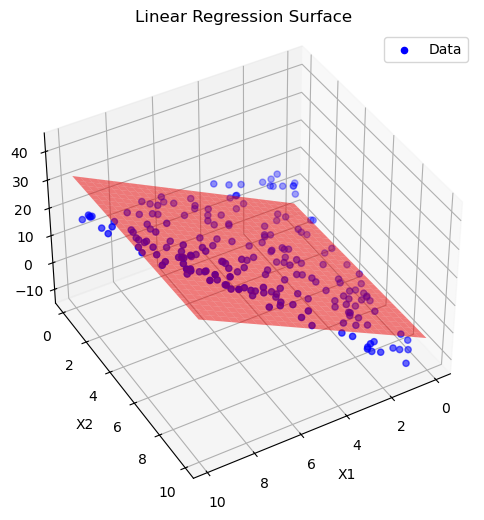

In [15]:
# Create meshgrid for surface
x1_range = np.linspace(X1.min(), X1.max(), 30)
x2_range = np.linspace(X2.min(), X2.max(), 30)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)
X_grid = np.column_stack([x1_grid.ravel(), x2_grid.ravel()])
y_grid_lin = lin_model.predict(X_grid).reshape(x1_grid.shape)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X1, X2, y, color='blue', label='Data')
ax.plot_surface(x1_grid, x2_grid, y_grid_lin, alpha=0.5, color='red')
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("y")
ax.view_init(elev=40, azim=60)
ax.set_title("Linear Regression Surface")
plt.legend()
plt.show()


## Polynomial Multiple Regression (degree 2)

In [16]:
poly_model = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
poly_model.fit(X, y)
y_pred_poly = poly_model.predict(X)

print("R^2 Score:", r2_score(y, y_pred_poly))


R^2 Score: 0.9757729554559231


### 3D Visualization: Polynomial Regression

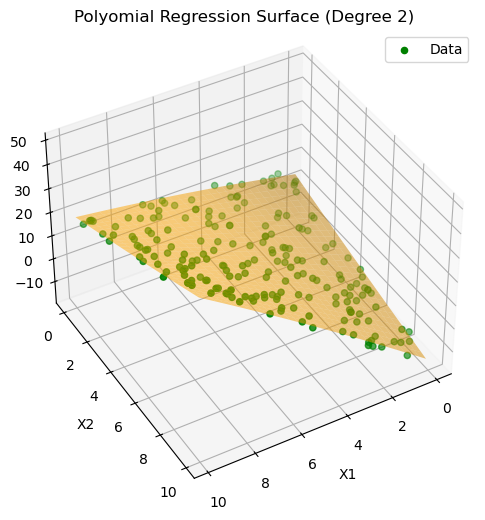

In [17]:
y_grid_poly = poly_model.predict(X_grid).reshape(x1_grid.shape)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X1, X2, y, color='green', label='Data')
ax.plot_surface(x1_grid, x2_grid, y_grid_poly, alpha=0.5, color='orange')
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("y")
ax.set_title("Polyomial Regression Surface (Degree 2)")
ax.view_init(elev=40, azim=60)
plt.legend()
plt.show()


### What is \( R^2 \)?  
The **coefficient of determination** \( R^2 \) measures how well the regression model fits the data. It is defined as:

$$
R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}
$$

Where:
- $y_i$ = true value for example $i$
- $\hat{y}_i$ = predicted value for $i$
- $\bar{y} = \frac{1}{n} \sum_i y_i$ - prediction using average
- $n$ number of examples

#### Interpretation of $R^2$

- $ R^2 = 1 $: perfect fit  
- $ R^2 = 0 $: model is no better than using the mean  
- $ R^2 < 0 $: model performs worse than predicting the mean


## Residual Plots

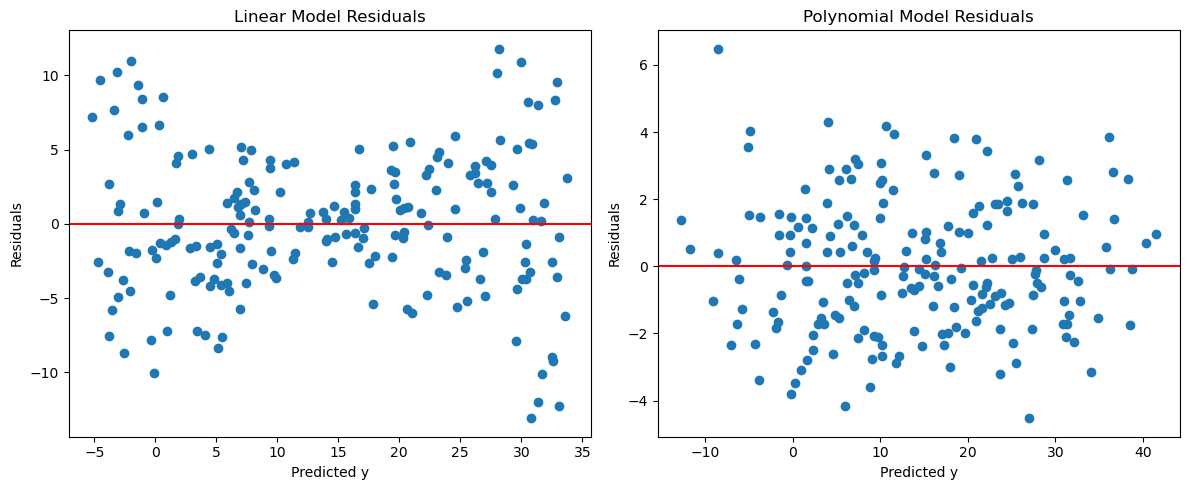

In [18]:
resid_lin = y - y_pred_lin
resid_poly = y - y_pred_poly

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_pred_lin, resid_lin)
plt.axhline(0, color='red')
plt.title("Linear Model Residuals")
plt.xlabel("Predicted y")
plt.ylabel("Residuals")

plt.subplot(1,2,2)
plt.scatter(y_pred_poly, resid_poly)
plt.axhline(0, color='red')
plt.title("Polynomial Model Residuals")
plt.xlabel("Predicted y")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()


## 3D Visualization of the Regression Surfaces
Below we plot the fitted surfaces for both the linear and polynomial regression models.

## Multiple polynomial regression in pyspark
This cell is for reference only, don't try running it as is.

In [11]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, PolynomialExpansion
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline

# Start Spark
spark = SparkSession.builder.appName("PolynomialRegression").getOrCreate()

# Sample Data
data = spark.createDataFrame([
    (1.0, 2.0, 10.0),
    (2.0, 3.0, 18.0),
    (3.0, 4.0, 28.0),
    (4.0, 5.0, 40.0),
    (5.0, 6.0, 54.0)
], ["x1", "x2", "y"])

# Assemble features into a single vector
assembler = VectorAssembler(inputCols=["x1", "x2"], outputCol="features")

# Apply polynomial expansion
polyExpansion = PolynomialExpansion(degree=2, inputCol="features", outputCol="polyFeatures")

# Linear regression on expanded features
lr = LinearRegression(featuresCol="polyFeatures", labelCol="y")

# Pipeline
pipeline = Pipeline(stages=[assembler, polyExpansion, lr])

# Fit model
model = pipeline.fit(data)

# Show coefficients
lr_model = model.stages[-1]
print("Intercept:", lr_model.intercept)
print("Coefficients:", lr_model.coefficients)

# Predict on training data
predictions = model.transform(data)
predictions.select("x1", "x2", "y", "prediction").show()


ModuleNotFoundError: No module named 'pyspark'